In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip -q install pyxdf numpy scipy

import os, re, glob
import numpy as np
from scipy import signal
import pyxdf
import matplotlib.pyplot as plt
import seaborn as sns

DATA_GLOB = "/content/drive/MyDrive/Competition Team/EEG Data/newGuiData/*.xdf"
FREQ_REGEX = r"(\d+(?:\.\d+)?)\s*hz"

LINE_FREQ = 60.0
BANDPASS = (0.5, 45.0)
RESAMPLE_HZ = 250

WIN_SEC = 2.0
STRIDE_SEC = 1.0
DROP_START_SEC = 1.0
DROP_END_SEC = 0.5

# Each band targets a specific frequency's fundamental or harmonic.
# Rule: every trained class must have at least one band that includes its
# fundamental. Bands can be shared (e.g. 7.5 Hz 2nd harmonic = 15 Hz
# fundamental at 14-16 Hz) — TRCA spatial filters separate classes within
# the same band using electrode geometry.
#
# Previous bands were broken:
#   (13, 45) was labeled "10hz fundamental" but 10 Hz is BELOW 13 Hz
#   7.5 Hz had no dedicated band at all
FB_BANDS = [
    (6,   9),   # 7.5 Hz fundamental
    (9,   11),  # 10 Hz fundamental
    (11,  13),  # 12 Hz fundamental
    (14,  16),  # 7.5 Hz 2nd harmonic (15 Hz) + 15 Hz fundamental
    (19,  21),  # 10 Hz 2nd harmonic (20 Hz)
    (23,  25),  # 12 Hz 2nd harmonic (24 Hz)
    (29,  31),  # 15 Hz 2nd harmonic (30 Hz)
]

WEIGHT_EXP = 1.25
SEED = 123
TEST_FRAC_FILES = 0.2

EEG_CHANNEL_IDXS = list(range(8))   # keeps columns 0..7

START_MARKERS = [
    "252.0"
]

END_MARKERS = [
    "253.0"
]

In [ ]:
# ---------------------------
# Helpers
# ---------------------------
def freq_from_name(path):
    m = re.search(FREQ_REGEX, os.path.basename(path).lower())
    if not m:
        raise ValueError(f"Can't parse freq from filename: {path}")
    return float(m.group(1))


def _safe_name(s):
    return s["info"].get("name", ["?"])[0]

def _safe_type(s):
    return s["info"].get("type", ["?"])[0]

def _ch_count(s):
    try:
        return int(s["info"]["channel_count"][0])
    except Exception:
        return 0

def pick_eeg_stream(streams):
    candidates = []
    for s in streams:
        ts = s.get("time_series", None)
        tt = s.get("time_stamps", None)
        if ts is None or tt is None or len(tt) == 0:
            continue
        arr = np.asarray(ts)
        # check both that data is 2D and has actual samples
        if arr.ndim == 2 and arr.shape[0] > 0 and arr.shape[1] > 1:
            candidates.append(s)

    if not candidates:
        raise ValueError("No EEG-like stream with samples found.")

    return max(candidates, key=lambda s: len(s["time_series"]))

def pick_marker_stream(streams):
    candidates = []
    for s in streams:
        name = _safe_name(s).lower()
        stype = _safe_type(s).lower()
        ts = s.get("time_series", None)
        tt = s.get("time_stamps", None)
        if ts is None or tt is None or len(ts) == 0 or len(tt) == 0:
            continue
        if "marker" in name or "marker" in stype or _ch_count(s) == 1:
            candidates.append(s)

    if not candidates:
        raise ValueError("No marker stream found.")

    return max(candidates, key=lambda s: len(s["time_series"]))

def marker_values_to_strings(marker_stream):
    vals = marker_stream["time_series"]
    out = []
    for v in vals:
        if isinstance(v, (list, tuple, np.ndarray)):
            if len(v) > 0:
                out.append(str(v[0]))
            else:
                out.append("")
        else:
            out.append(str(v))
    return np.array(out, dtype=object)

def load_xdf_eeg_and_markers(path):
    streams, _ = pyxdf.load_xdf(path)

    eeg_stream = pick_eeg_stream(streams)

    marker_stream = pick_marker_stream(streams)

    X = np.asarray(eeg_stream["time_series"], dtype=np.float64)
    t_eeg = np.asarray(eeg_stream["time_stamps"], dtype=np.float64)

    if X.ndim == 1:
        X = X[:, None]

    X = X[:, EEG_CHANNEL_IDXS]

    X = X.T  # (n_ch, n_samples)

    sfreq = 1.0 / np.median(np.diff(t_eeg))

    marker_labels = marker_values_to_strings(marker_stream)
    marker_times = np.asarray(marker_stream["time_stamps"], dtype=np.float64)

    return X, t_eeg, sfreq, marker_labels, marker_times, eeg_stream, marker_stream


def build_test_intervals(marker_labels, marker_times, start_markers, end_markers):
    start_set = set(start_markers)
    end_set = set(end_markers)

    intervals = []
    active_start = None

    for label, t in zip(marker_labels, marker_times):
        if label in start_set and active_start is None:
            active_start = t
        elif label in end_set and active_start is not None:
            if t > active_start:
                intervals.append((active_start, t))
            active_start = None

    return intervals

def timestamps_to_indices(eeg_timestamps, t_start, t_end):
    i0 = np.searchsorted(eeg_timestamps, t_start, side="left")
    i1 = np.searchsorted(eeg_timestamps, t_end, side="right")
    return i0, i1

def cut_eeg_to_intervals(X, eeg_timestamps, intervals):
    pieces = []
    for t0, t1 in intervals:
        i0, i1 = timestamps_to_indices(eeg_timestamps, t0, t1)
        if i1 > i0:
            pieces.append(X[:, i0:i1])

    if not pieces:
        raise ValueError("No EEG samples found inside the chosen test intervals.")

    return pieces


def load_eeg_xdf_trials_only(path, start_markers, end_markers):
    X, t_eeg, sfreq, marker_labels, marker_times, eeg_stream, marker_stream = load_xdf_eeg_and_markers(path)

    intervals = build_test_intervals(marker_labels, marker_times, start_markers, end_markers)
    if not intervals:
        raise ValueError(f"No valid trial intervals found in file: {path}")

    pieces = cut_eeg_to_intervals(X, t_eeg, intervals)

    # preprocess each trial independently to avoid filter artifacts at join points
    processed_pieces = []
    processed_sfreq = None
    for piece in pieces:
        piece_proc, sf = preprocess(piece, sfreq)
        processed_pieces.append(piece_proc)
        processed_sfreq = sf

    X = np.concatenate(processed_pieces, axis=1)
    return X, processed_sfreq

In [ ]:
def preprocess(X, sfreq):
    # average reference
    X = X - X.mean(axis=0, keepdims=True)

    # notch at line (60hz) + harmonics (120hz, 180hz)
    nyq = sfreq / 2
    nf = LINE_FREQ
    while nf < nyq:
        b, a = signal.iirnotch(w0=nf, Q=30, fs=sfreq)
        X = signal.filtfilt(b, a, X, axis=-1)
        nf += LINE_FREQ

    # bandpass
    sos = signal.butter(4, [BANDPASS[0], BANDPASS[1]], btype="bandpass", fs=sfreq, output="sos")

    # apply bandpass forward and backward to avoid phase shifting
    X = signal.sosfiltfilt(sos, X, axis=-1)

    # resample
    if abs(sfreq - RESAMPLE_HZ) > 1e-9:
        n_out = int(round(X.shape[1] * (RESAMPLE_HZ / sfreq)))
        X = signal.resample(X, n_out, axis=-1)
        sfreq = float(RESAMPLE_HZ)

    return X, sfreq

def windowize(X, sfreq, amp_threshold=100.0):
    start = int(round(DROP_START_SEC * sfreq))
    end = X.shape[1] - int(round(DROP_END_SEC * sfreq))
    win = int(round(WIN_SEC * sfreq))
    stride = int(round(STRIDE_SEC * sfreq))

    if end - start < win:
        raise ValueError("Not enough data after drops to make 1 window.")

    trials = []
    for s in range(start, end - win + 1, stride):
        epoch = X[:, s:s+win]
        epoch = signal.detrend(epoch, axis=-1, type="linear")
        std = epoch.std(axis=-1, keepdims=True) + 1e-12
        epoch = epoch / std
        # Reject epoch if any channel has peak-to-peak > threshold
        ptp = epoch.max(axis=-1) - epoch.min(axis=-1)
        if np.any(ptp > amp_threshold):
            continue
        trials.append(epoch)

    if not trials:
        raise ValueError("All epochs rejected — lower amp_threshold or check data quality.")
    return np.stack(trials, axis=0)


def split_files(paths, seed=SEED, test_frac=TEST_FRAC_FILES):
    rng = np.random.default_rng(seed)

    by_f = {}
    for p in paths:
        f = freq_from_name(p)
        by_f.setdefault(f, []).append(p)

    test, train = [], []
    for f, ps in by_f.items():
        ps = ps.copy()
        rng.shuffle(ps)

        if len(ps) <= 1:
            # can't hold out a file for this class; keep it in train
            train.extend(ps)
            continue

        n_test = max(1, int(round(len(ps) * test_frac)))
        test.extend(ps[:n_test])
        train.extend(ps[n_test:])

    return train, test

def balance_classes_to_min(X, y, shuffle_within_class=False, seed=SEED):
    """
    Downsample every class to the size of the smallest class by discarding
    extra windows after that class reaches the minimum count.

    Parameters
    ----------
    X : np.ndarray
        Shape (n_windows, n_ch, n_times)
    y : np.ndarray
        Shape (n_windows,)
    shuffle_within_class : bool
        If False, keeps the first min_count windows from each class.
        If True, randomly chooses min_count windows from each class.
    seed : int
        Random seed used only if shuffle_within_class=True.

    Returns
    -------
    X_bal : np.ndarray
    y_bal : np.ndarray
    """
    X = np.asarray(X)
    y = np.asarray(y)

    classes, counts = np.unique(y, return_counts=True)
    min_count = counts.min()

    keep_idxs = []
    rng = np.random.default_rng(seed)

    for cls in classes:
        cls_idxs = np.where(y == cls)[0]

        if shuffle_within_class:
            cls_idxs = rng.permutation(cls_idxs)

        keep_idxs.extend(cls_idxs[:min_count])

    keep_idxs = np.array(sorted(keep_idxs))
    return X[keep_idxs], y[keep_idxs]

In [ ]:
# ---------------------------
# Build dataset
# ---------------------------
paths = sorted(glob.glob(DATA_GLOB))
if not paths:
    raise ValueError(f"No files matched {DATA_GLOB}")

freqs = sorted({freq_from_name(p) for p in paths})
freq_to_class = {f:i for i,f in enumerate(freqs)}
print("Classes (freqs):", freqs)

train_files, test_files = split_files(paths)
print("Train files:", len(train_files), "Test files:", len(test_files))


def build_Xy(file_list):
  Xs, ys = [], []
  sf_seen = None
  for p in file_list:

      try:
          # Get frequency and class
          f = freq_from_name(p)
          cls = freq_to_class[f]

          # Load trials
          X, sf = load_eeg_xdf_trials_only(p, START_MARKERS, END_MARKERS)

          if sf_seen is None:
              sf_seen = sf
          elif abs(sf - sf_seen) > 1e-6:
              raise ValueError("Sampling rate mismatch after resample (shouldn't happen).")

          trials = windowize(X, sf)
          Xs.append(trials)
          ys.append(np.full((trials.shape[0],), cls, dtype=int))

      except Exception as e:
          print(f"  SKIPPED: {e}")
          continue

  if not Xs:
      raise ValueError("No valid files loaded.")

  return np.concatenate(Xs, axis=0), np.concatenate(ys, axis=0), sf_seen

Classes (freqs): [7.5, 10.0, 12.0, 15.0]
Train files: 16 Test files: 4


In [ ]:
# ============================================================
# FBTRCA
# ============================================================

def corrcoef_1d(a, b, eps=1e-12):
    a = a - a.mean()
    b = b - b.mean()
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + eps
    return float((a @ b) / denom)

def bandpass_sos(low, high, fs, order=4):
    return signal.butter(order, [low, high], btype="bandpass", fs=fs, output="sos")

def apply_sos(X, sos):
    return signal.sosfiltfilt(sos, X, axis=-1)

def trca_fit(X_class, reg=1e-6):
    """
    X_class: (n_trials, n_ch, n_times)
    """
    X_class = np.asarray(X_class, dtype=np.float64)
    n_trials, n_ch, n_times = X_class.shape

    template = X_class.mean(axis=0)
    Xc = X_class - X_class.mean(axis=2, keepdims=True)

    Q = np.zeros((n_ch, n_ch), dtype=np.float64)
    for i in range(n_trials):
        Xi = Xc[i]
        Q += Xi @ Xi.T

    Z = Xc.sum(axis=0)
    S = Z @ Z.T - Q

    Q = Q + reg * np.eye(n_ch)
    A = np.linalg.solve(Q, S)
    eigvals, eigvecs = np.linalg.eig(A)
    w = np.real(eigvecs[:, np.argmax(np.real(eigvals))])
    w = w / (np.linalg.norm(w) + 1e-12)
    return w, template

def trca_score(epoch, w, template):
    y = w @ epoch
    yt = w @ template
    return corrcoef_1d(y, yt)

class FBTRCA:
    def __init__(self, sfreq, filter_bands, weight_exp=1.25, trca_reg=1e-6):
        self.sfreq = sfreq
        self.filter_bands = filter_bands
        self.weight_exp = weight_exp
        self.trca_reg = trca_reg
        self.sos = [bandpass_sos(lo, hi, sfreq) for lo, hi in filter_bands]
        self.band_weights = np.array([1/((i+1)**weight_exp) for i in range(len(filter_bands))], dtype=np.float64)
        self.models = None
        self.K = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=int)
        self.K = int(y.max()) + 1

        self.models = []  # [band][cls] -> (w, template)
        for bi, sos in enumerate(self.sos):
            Xb = apply_sos(X, sos)  # (n_trials,n_ch,n_times)
            band_models = []
            for k in range(self.K):
                Xk = Xb[y == k]
                if len(Xk) < 2:
                    raise ValueError(f"Class {k} has <2 trials; TRCA needs multiple trials/class.")
                w, templ = trca_fit(Xk, reg=self.trca_reg)
                band_models.append((w, templ))
            self.models.append(band_models)
        return self

    def predict_scores(self, epoch):
        epoch = np.asarray(epoch, dtype=np.float64)
        per_band = np.zeros((len(self.sos), self.K), dtype=np.float64)
        for bi, sos in enumerate(self.sos):
            eb = apply_sos(epoch, sos)  # (n_ch,n_times)
            for k in range(self.K):
                w, templ = self.models[bi][k]
                per_band[bi, k] = trca_score(eb, w, templ)
        fused = (self.band_weights[:, None] * (per_band ** 2)).sum(axis=0)
        return fused, per_band

    def predict(self, epoch):
        fused, _ = self.predict_scores(epoch)
        return int(np.argmax(fused)), fused

In [ ]:
# ---------------------------
# Train + evaluate FBTRCA
# ---------------------------
Xtr, ytr, sfreq = build_Xy(train_files)
# Xtr, ytr = balance_classes_to_min(Xtr, ytr, shuffle_within_class=False) # REMOVE LATER -> THIS BALANCES CLASSES DOWN

print("Train windows:", Xtr.shape)

# Train model
model = FBTRCA(sfreq=sfreq, filter_bands=FB_BANDS, weight_exp=WEIGHT_EXP, trca_reg=1e-6).fit(Xtr, ytr)

if len(test_files) > 0:
    Xte, yte, _ = build_Xy(test_files)
    # Xte, yte = balance_classes_to_min(Xte, yte, shuffle_within_class=False)

    pred = np.array([model.predict(ep)[0] for ep in Xte], dtype=int)
    acc = float((pred == yte).mean())
    print(f"Test accuracy: {acc*100:.2f}%")
else:
    print("No held-out test files available (need >=2 files per class for file-level test).")


Train windows: (896, 8, 500)
Test accuracy: 80.10%



Overall accuracy: 80.10%
Average certainty:              22.6%
Average certainty (correct):    25.7%
Average certainty (incorrect):  10.3%


7.5hz — acc: 91.2%  avg certainty: 22.4%
10.0hz — acc: 82.5%  avg certainty: 24.2%
12.0hz — acc: 91.7%  avg certainty: 28.7%
15.0hz — acc: 50.0%  avg certainty: 14.0%

Mean class accuracy: 78.84%




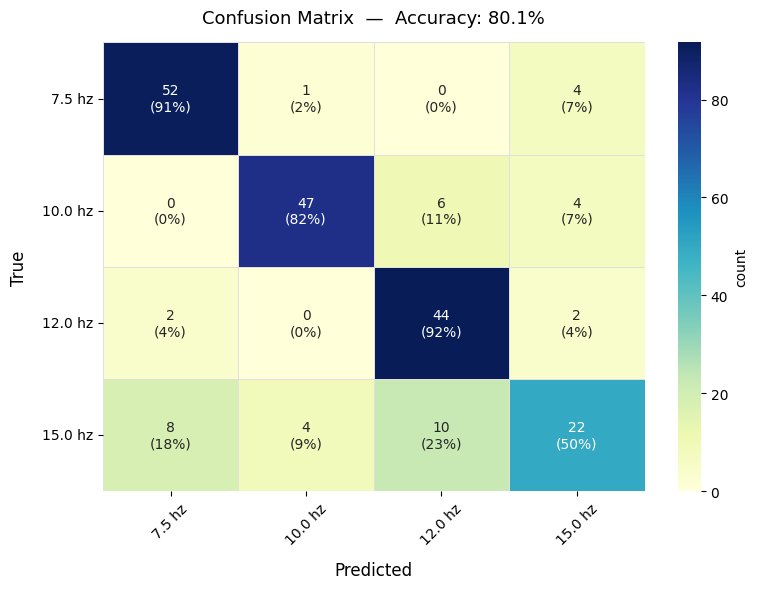

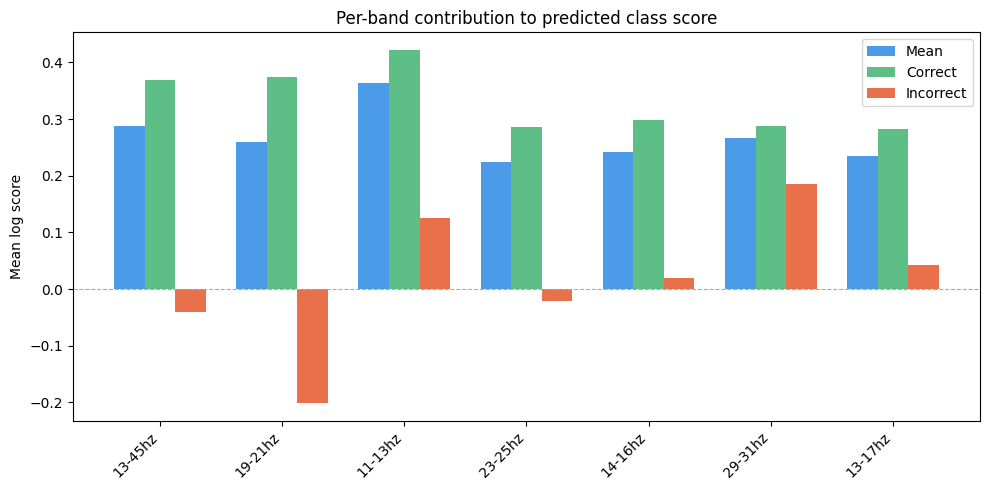

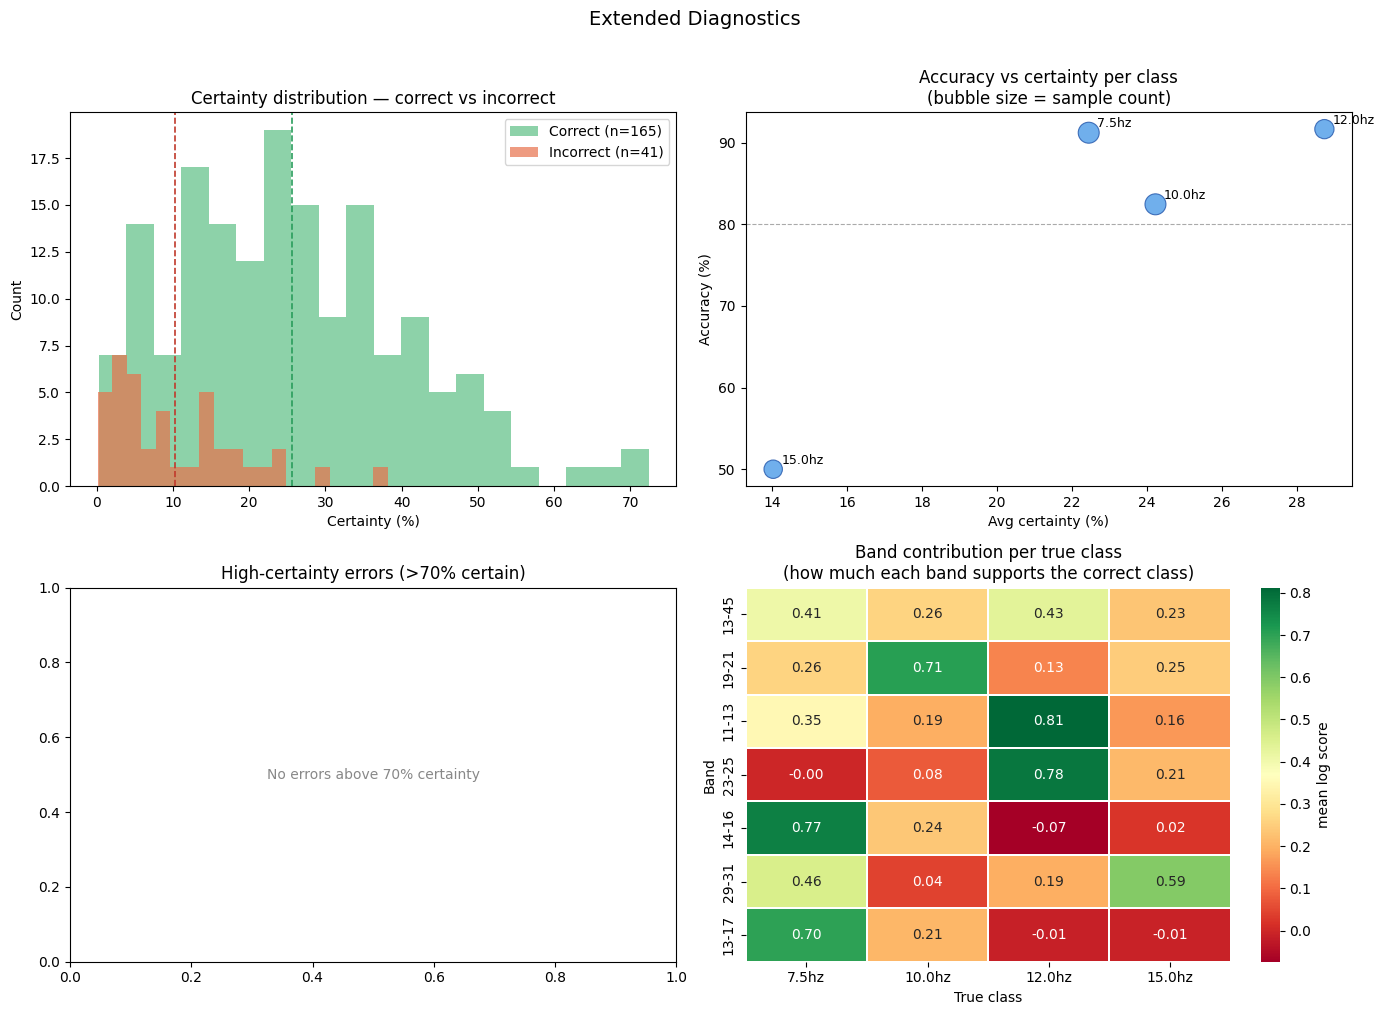

In [ ]:
if len(test_files) > 0:
    Xte, yte, _ = build_Xy(test_files)

    certainties = []
    correct_mask = []
    all_preds = []
    band_scores_log = []

    for i, ep in enumerate(Xte):
        pred_class, fused_scores = model.predict(ep)
        _, per_band = model.predict_scores(ep)
        true_class = yte[i]
        pred_freq = freqs[pred_class]
        true_freq = freqs[true_class]
        correct = pred_class == true_class

        if len(freqs) > 1:
          sorted_scores = np.sort(fused_scores)[::-1]
          certainty = (sorted_scores[0] - sorted_scores[1]) / (sorted_scores[0] + sorted_scores[1] + 1e-12)
          certainty_pct = certainty * 100
        else:
          certainty_pct = 100.0

        certainties.append(certainty_pct)
        correct_mask.append(correct)
        all_preds.append(pred_class)
        band_scores_log.append(per_band)

        dominant_band = int(np.argmax([per_band[b, pred_class] for b in range(len(FB_BANDS))]))
        band_range = f"{FB_BANDS[dominant_band][0]}-{FB_BANDS[dominant_band][1]}hz"

    certainties = np.array(certainties)
    correct_mask = np.array(correct_mask)
    all_preds = np.array(all_preds)
    band_scores_log = np.array(band_scores_log)  # (n_windows, n_bands, n_classes)

    acc = correct_mask.mean()

    # --- Summary stats ---
    print(f"\nOverall accuracy: {acc*100:.2f}%")
    print(f"Average certainty:             {certainties.mean():5.1f}%")
    if correct_mask.any():
        print(f"Average certainty (correct):   {certainties[correct_mask].mean():5.1f}%")
    if (~correct_mask).any():
        print(f"Average certainty (incorrect): {certainties[~correct_mask].mean():5.1f}%")

    print("\n")

    class_accs = []
    for cls_idx, freq in enumerate(freqs):
      mask = yte == cls_idx
      cls_acc = correct_mask[mask].mean()
      cls_certainty = certainties[mask].mean()
      class_accs.append(cls_acc)
      print(f"{freq}hz — acc: {cls_acc*100:.1f}%  avg certainty: {cls_certainty:.1f}%")

    mean_class_acc = np.mean(class_accs)
    print(f"\nMean class accuracy: {mean_class_acc*100:.2f}%")

    print("\n")

    # --- Confusion matrix ---
    n = len(freqs)
    cm = np.zeros((n, n), dtype=int)
    for true_idx in range(n):
        for pred_idx in range(n):
            cm[true_idx, pred_idx] = ((yte == true_idx) & (all_preds == pred_idx)).sum()

    # Compute per-row percentages for annotations
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([
        [f"{cm[i,j]}\n({cm_pct[i,j]:.0f}%)" for j in range(n)]
        for i in range(n)
    ])

    labels = [f"{f} hz" for f in freqs]
    accuracy = np.trace(cm) / cm.sum() * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_pct, annot=annot, fmt="", cmap="YlGnBu",
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5, linecolor="#e0e0e0",
        cbar_kws={"label": "count"},
        ax=ax
    )

    ax.set_xlabel("Predicted", fontsize=12, labelpad=10)
    ax.set_ylabel("True", fontsize=12, labelpad=10)
    ax.set_title(f"Confusion Matrix  —  Accuracy: {accuracy:.1f}%", fontsize=13, pad=14)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()

    # --- Per-band contribution ---
    band_labels, means, corrects, incorrects = [], [], [], []

    for bi, (lo, hi) in enumerate(FB_BANDS):
        band_contrib = np.array([band_scores_log[i, bi, all_preds[i]] for i in range(len(Xte))])
        band_labels.append(f"{lo}-{hi}hz")
        means.append(band_contrib.mean())
        corrects.append(band_contrib[correct_mask].mean())
        incorrects.append(band_contrib[~correct_mask].mean() if (~correct_mask).any() else np.nan)

    x = np.arange(len(band_labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, means,     width, label="Mean",      color="#4C9BE8")
    ax.bar(x,         corrects,  width, label="Correct",   color="#5DBF85")
    ax.bar(x + width, incorrects,width, label="Incorrect", color="#E8714C")

    ax.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(band_labels, rotation=45, ha="right")
    ax.set_ylabel("Mean log score")
    ax.set_title("Per-band contribution to predicted class score")
    ax.legend()

    plt.tight_layout()
    plt.show()



    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Extended Diagnostics", fontsize=14, y=1.01)

    # --- 1. Certainty distribution: correct vs incorrect ---
    ax = axes[0, 0]
    ax.hist(certainties[correct_mask],   bins=20, alpha=0.7, color="#5DBF85", label=f"Correct (n={correct_mask.sum()})")
    ax.hist(certainties[~correct_mask],  bins=20, alpha=0.7, color="#E8714C", label=f"Incorrect (n={(~correct_mask).sum()})")
    ax.axvline(certainties[correct_mask].mean(),  color="#2a9d5c", linestyle="--", linewidth=1.2)
    ax.axvline(certainties[~correct_mask].mean(), color="#c0392b", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Certainty (%)")
    ax.set_ylabel("Count")
    ax.set_title("Certainty distribution — correct vs incorrect")
    ax.legend()

    # --- 2. Per-class accuracy vs avg certainty scatter ---
    ax = axes[0, 1]
    cls_accs, cls_certs, cls_ns = [], [], []
    for cls_idx in range(len(freqs)):
        mask = yte == cls_idx
        cls_accs.append(correct_mask[mask].mean() * 100)
        cls_certs.append(certainties[mask].mean())
        cls_ns.append(mask.sum())

    scatter = ax.scatter(cls_certs, cls_accs, s=[n * 4 for n in cls_ns],
                        color="#4C9BE8", alpha=0.8, edgecolors="#2255aa", linewidths=0.8)
    for i, freq in enumerate(freqs):
        ax.annotate(f"{freq}hz", (cls_certs[i], cls_accs[i]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
    ax.set_xlabel("Avg certainty (%)")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy vs certainty per class\n(bubble size = sample count)")
    ax.axhline(acc * 100, color="#aaaaaa", linestyle="--", linewidth=0.8)

    # --- 3. High-certainty errors: where do they go? ---
    ax = axes[1, 0]
    certainty_threshold = 70
    high_cert_wrong = (~correct_mask) & (certainties > certainty_threshold)
    if high_cert_wrong.any():
        pair_counts = {}
        for i in np.where(high_cert_wrong)[0]:
            key = (freqs[yte[i]], freqs[all_preds[i]])
            pair_counts[key] = pair_counts.get(key, 0) + 1
        pairs = sorted(pair_counts.items(), key=lambda x: -x[1])[:10]
        pair_labels = [f"{t}→{p}hz" for (t, p), _ in pairs]
        pair_vals   = [v for _, v in pairs]
        ax.barh(pair_labels[::-1], pair_vals[::-1], color="#E8714C")
        ax.set_xlabel("Count")
        ax.set_title(f"High-certainty errors (>{certainty_threshold}% certain)\ntrue → predicted")
    else:
        ax.text(0.5, 0.5, f"No errors above {certainty_threshold}% certainty",
                ha="center", va="center", transform=ax.transAxes, color="#888888")
        ax.set_title(f"High-certainty errors (>{certainty_threshold}% certain)")

    # --- 4. Band score heatmap per true class ---
    ax = axes[1, 1]
    band_class_matrix = np.zeros((len(FB_BANDS), len(freqs)))
    for cls_idx in range(len(freqs)):
        mask = yte == cls_idx
        if mask.any():
            for bi in range(len(FB_BANDS)):
                band_class_matrix[bi, cls_idx] = band_scores_log[mask, bi, cls_idx].mean()

    band_tick_labels = [f"{lo}-{hi}" for lo, hi in FB_BANDS]
    sns.heatmap(band_class_matrix, ax=ax, cmap="RdYlGn",
                xticklabels=[f"{f}hz" for f in freqs],
                yticklabels=band_tick_labels,
                annot=True, fmt=".2f", linewidths=0.3,
                cbar_kws={"label": "mean log score"})
    ax.set_xlabel("True class")
    ax.set_ylabel("Band")
    ax.set_title("Band contribution per true class\n(how much each band supports the correct class)")

    plt.tight_layout()
    plt.show()

else:
    print("No held-out test files available.")

In [ ]:
# Saving the FBTRCA model to my PC to integrate into live data pipeline
# Improvements to the model can be saved and inserted into the live data pipeline to improve performance
# From Keira

import pickle
from google.colab import files

# Creating a dictionary with the model and hyperparameters combined

model_info = {
    # Trained model
    "model": model,

    # Preset constants
    "freqs": freqs,
    "freq_to_class": freq_to_class,
    "sfreq": sfreq,
    "win_sec": WIN_SEC,
    "stride_sec": STRIDE_SEC,
    "drop_start_sec": DROP_START_SEC,
    "drop_end_sec": DROP_END_SEC,
    "line_freq": LINE_FREQ,
    "bandpass": BANDPASS,
    "resample_hz": RESAMPLE_HZ,
    "fb_bands": FB_BANDS,
    "weight_exp": WEIGHT_EXP,
}

with open("/content/fbtrca_model.pkl", "wb") as f:
    pickle.dump(model_info, f)

files.download("/content/fbtrca_model.pkl")

print("Full model + metadata saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Full model + metadata saved!


In [ ]:
for i, f in enumerate(freqs):
    count = (ytr == i).sum()
    print(f"{f}hz: {count} windows")

7.5hz: 132 windows
10.0hz: 294 windows
12.0hz: 279 windows
15.0hz: 191 windows


In [ ]:
def find_bad_files(paths):
    bad = []
    for p in paths:
        reason = None
        try:
            streams, _ = pyxdf.load_xdf(p)

            # check EEG stream
            eeg_ok = False
            marker_ok = False

            for s in streams:
                ts = s.get("time_series", None)
                tt = s.get("time_stamps", None)
                if ts is None or tt is None:
                    continue
                arr = np.asarray(ts)
                if arr.ndim == 2 and arr.shape[0] > 0 and arr.shape[1] > 1:
                    eeg_ok = True
                if arr.ndim >= 1 and arr.shape[0] > 0:
                    name = s["info"].get("name", [""])[0].lower()
                    stype = s["info"].get("type", [""])[0].lower()
                    if "marker" in name or "marker" in stype:
                        marker_ok = True

            if not eeg_ok:
                reason = "empty EEG stream"
            elif not marker_ok:
                reason = "empty marker stream"
            else:
                # also check freq parseable and trials extractable
                try:
                    freq_from_name(p)
                except ValueError:
                    reason = "can't parse frequency from filename"

        except Exception as e:
            reason = f"failed to load: {e}"

        if reason:
            bad.append((p, reason))

    if bad:
        print(f"Found {len(bad)} bad files:\n")
        for p, r in bad:
            print(f"  {r}")
            print(f"  {p}\n")
    else:
        print("All files look good.")

    return [p for p, _ in bad]

all_paths = sorted(glob.glob(DATA_GLOB), key=lambda p: os.path.basename(p).lower())
bad_files = find_bad_files(all_paths)

All files look good.


In [ ]:
def check_dead_files(paths):
    print(f"{'FILE':<60} {'DEFAULT':>10} {'PERMISSIVE':>12}")
    print("-" * 85)

    for p in paths:
        name = os.path.basename(p)

        # default pyxdf
        try:
            streams, _ = pyxdf.load_xdf(p)
            default_samples = max(
                (np.asarray(s.get("time_series", [])).shape[0]
                 for s in streams
                 if np.asarray(s.get("time_series", [])).ndim == 2
                 and np.asarray(s.get("time_series", [])).shape[1] > 1),
                default=0
            )
        except Exception as e:
            default_samples = "ERR"

        # permissive pyxdf
        try:
            streams, _ = pyxdf.load_xdf(
                p,
                synchronize_clocks=False,
                dejitter_timestamps=False
            )
            permissive_samples = max(
                (np.asarray(s.get("time_series", [])).shape[0]
                 for s in streams
                 if np.asarray(s.get("time_series", [])).ndim == 2
                 and np.asarray(s.get("time_series", [])).shape[1] > 1),
                default=0
            )
        except Exception as e:
            permissive_samples = "ERR"

        print(f"{name:<60} {str(default_samples):>10} {str(permissive_samples):>12}")

# run on your dead files
dead_files = [p for p in bad_files]  # from find_bad_files earlier
check_dead_files(dead_files)

FILE                                                            DEFAULT   PERMISSIVE
-------------------------------------------------------------------------------------


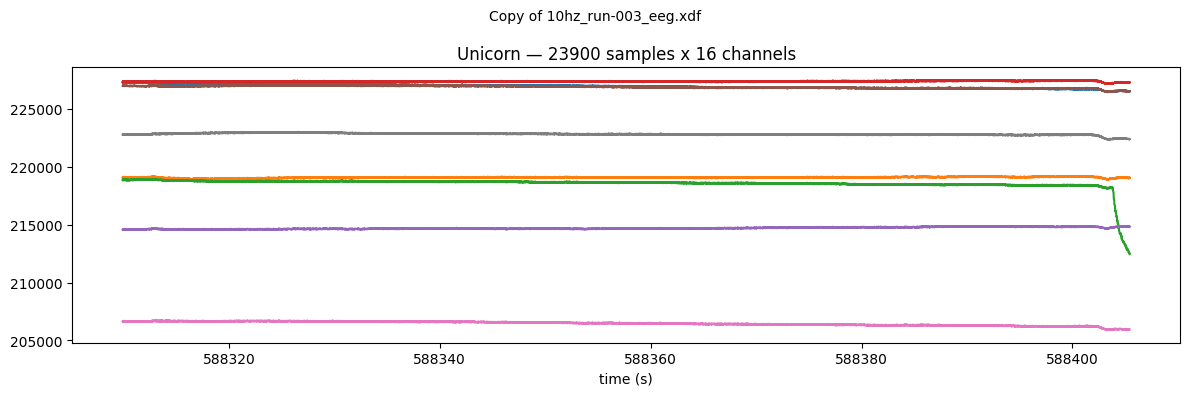

In [ ]:
import matplotlib.pyplot as plt

def plot_xdf_data(path):
    streams, _ = pyxdf.load_xdf(path, synchronize_clocks=False, dejitter_timestamps=False)

    eeg_streams = []
    for s in streams:
        arr = np.asarray(s.get("time_series", []))
        if arr.ndim == 2 and arr.shape[1] > 1:
            eeg_streams.append((s, arr))

    if not eeg_streams:
        print(f"NO EEG DATA: {os.path.basename(path)}")
        fig, ax = plt.subplots(figsize=(12, 2))
        ax.text(0.5, 0.5, "NO EEG DATA", ha="center", va="center",
                fontsize=20, color="red", transform=ax.transAxes)
        ax.set_title(os.path.basename(path))
        plt.show()
        return

    fig, axes = plt.subplots(len(eeg_streams), 1, figsize=(12, 4 * len(eeg_streams)))
    if len(eeg_streams) == 1:
        axes = [axes]

    fig.suptitle(os.path.basename(path), fontsize=10)

    for (s, arr), ax in zip(eeg_streams, axes):
        name = s["info"].get("name", ["?"])[0]
        tt = np.asarray(s.get("time_stamps", []))
        ax.plot(tt, arr[:, :min(8, arr.shape[1])])
        ax.set_title(f"{name} — {arr.shape[0]} samples x {arr.shape[1]} channels")
        ax.set_xlabel("time (s)")

    plt.tight_layout()
    plt.show()

plot_xdf_data(train_files[0])
if len(dead_files) > 0:
  plot_xdf_data(dead_files[0])

In [ ]:
for p in train_files:
    streams, _ = pyxdf.load_xdf(p)
    for s in streams:
        arr = np.asarray(s.get("time_series", []))
        if arr.ndim == 2 and arr.shape[1] > 1 and arr.shape[0] > 0:
            print(f"{os.path.basename(p)}: min={arr.min():.1f}, max={arr.max():.1f}, mean={arr.mean():.1f}")

Copy of 10hz_run-003_eeg.xdf: min=-36.3, max=227489.7, mean=123177.7
Copy of sub-Yuta_ses-10hz_task-Default_run-002_eeg.xdf: min=-14.9, max=228255.7, mean=119046.1
Copy of sub-Yuta_ses-10hz_task-Default_run-004_eeg.xdf: min=-16.5, max=259821.0, mean=121375.1
Copy of sub-Yuta_ses-10hz_task-Default_run-001_eeg.xdf: min=-23.6, max=228808.7, mean=118155.2
Copy of yuta_10hz_run-002_eeg_old1.xdf: min=-18.7, max=229600.5, mean=114887.4
Copy of 15hz_run-005_eeg.xdf: min=-17.7, max=288854.0, mean=126980.9
Copy of sub-Yuta_ses-15Hz_task-Default_run-001_eeg_old1.xdf: min=-25.5, max=236771.5, mean=117399.0
Copy of 15hz_run-006_eeg.xdf: min=-19.4, max=310624.0, mean=128576.4
Copy of yuta_12hz_run-002_eeg.xdf: min=-10.8, max=228537.5, mean=118904.9
Copy of sub-Yuta_ses-12hz_task-Default_run-001_eeg.xdf: min=-16.5, max=388004.0, mean=128106.6
Copy of sub-Yuta_ses-12hz_task-Default_run-002_eeg.xdf: min=-20.2, max=357120.0, mean=126360.0
Copy of sub-Yuta_ses-12hz_task-Default_run-001_eeg_old1.xdf: min=